# League of Legends Meta Analysis
### Champion-Level Insights

This notebook queries the derived database and visualizes champion performance across five categories:
1. Champion Presence (pick/ban rates)
2. Best Champions by Lane
3. Patch Trends
4. Matchups
5. Synergies

In [1]:
import sys
import sqlite3

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sys.path.append("..")

from analysis.champions import (
    MASTER_PLUS,
    DIAMOND_PLUS,
    EMERALD_PLUS,
    PLATINUM_PLUS,
    get_champion_stats,
    get_best_champions,
    get_patch_trends,
    get_matchups,
    get_synergies,
    get_presence
)

def _normalize_champion(db_path, champion: str) -> str | None:
    """
    Find the exact champion name in the DB matching the input case-insensitively.
    Returns None if no match found.
    """
    conn = sqlite3.Connection(db_path)
    result = conn.execute(
        "SELECT DISTINCT champion FROM champion_stats WHERE LOWER(champion) = LOWER(?)",
        (champion.replace(" ", ""),)
    ).fetchone()
    conn.close()
    return result[0] if result else None

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------

DERIVED_DB = "../derived.db"

TIER = MASTER_PLUS # "CHALLENGER", MASTER_PLUS, or None for all.
VERSION = "16.10" # "16.10" 
MIN_GAMES = 50 # minimum games for a champion to appear in analysis
MIN_MATCHUP_GAMES = 25 # minimum games for a matchup/synergy to appear

In [3]:
TIER_LABELS = {
    None: "All Ranks",
    "CHALLENGER": "Challenger",
    "GRANDMASTER": "Grandmaster",
    "MASTER": "Master",
    "DIAMOND": "Diamond",
    "EMERALD": "Emerald",
    "PLATINUM": "Platinum",
    "GOLD": "Gold",
    "SILVER": "Silver",
    "BRONZE": "Bronze",
    "IRON": "Iron"
}

def tier_label(tier):
    if tier is None:
        return "All Ranks"
    if isinstance(tier, str):
        tier = tier.upper()
        return TIER_LABELS.get(tier, tier)
    if tier == MASTER_PLUS:
        return "Master+"
    if tier == DIAMOND_PLUS:
        return "Diamond+"
    if tier == EMERALD_PLUS:
        return "Emerald+"
    if tier == PLATINUM_PLUS:
        return "Platinum+"
    return " / ".join(TIER_LABELS.get(t, t) for t in tier)

---
## 1. Champion Presence
Pick rate, ban rate, and presence rate across all champions.

In [4]:
presence_df = get_presence(db_path=DERIVED_DB, tier=TIER, version=VERSION, min_games=MIN_GAMES)
presence_df.head(20)

,champion,total_matches,picks_top,picks_jungle,picks_middle,picks_bottom,picks_support,pick_rate_top,pick_rate_jungle,pick_rate_middle,pick_rate_bottom,pick_rate_support,bans,ban_rate,presence_rate
0,Smolder,26798,79,0,178,4134,1,0.0029,0.0000,0.0066,0.1543,0.0000,20649,0.7705,0.9344
1,Graves,26798,10,3436,18,2,1,0.0004,0.1282,0.0007,0.0001,0.0000,11451,0.4273,0.5567
2,Zed,26798,209,328,2109,17,13,0.0078,0.0122,0.0787,0.0006,0.0005,10358,0.3865,0.4864
3,Pyke,26798,1,1,44,3,1760,0.0000,0.0000,0.0016,0.0001,0.0657,10943,0.4084,0.4759
4,Naafiri,26798,134,1189,573,15,11,0.0050,0.0444,0.0214,0.0006,0.0004,8719,0.3254,0.3971
5,Yasuo,26798,747,2,1893,500,2,0.0279,0.0001,0.0706,0.0187,0.0001,6512,0.2430,0.3603
6,Akali,26798,643,1,1675,3,4,0.0240,0.0000,0.0625,0.0001,0.0001,7209,0.2690,0.3558
7,Draven,26798,114,28,48,1770,2,0.0043,0.0010,0.0018,0.0660,0.0001,7520,0.2806,0.3538
8,Ambessa,26798,1233,1078,137,0,4,0.0460,0.0402,0.0051,0.0000,0.0001,6417,0.2395,0.3310
9,Rengar,26798,90,1307,0,3,39,0.0034,0.0488,0.0000,0.0001,0.0015,6186,0.2308,0.2845


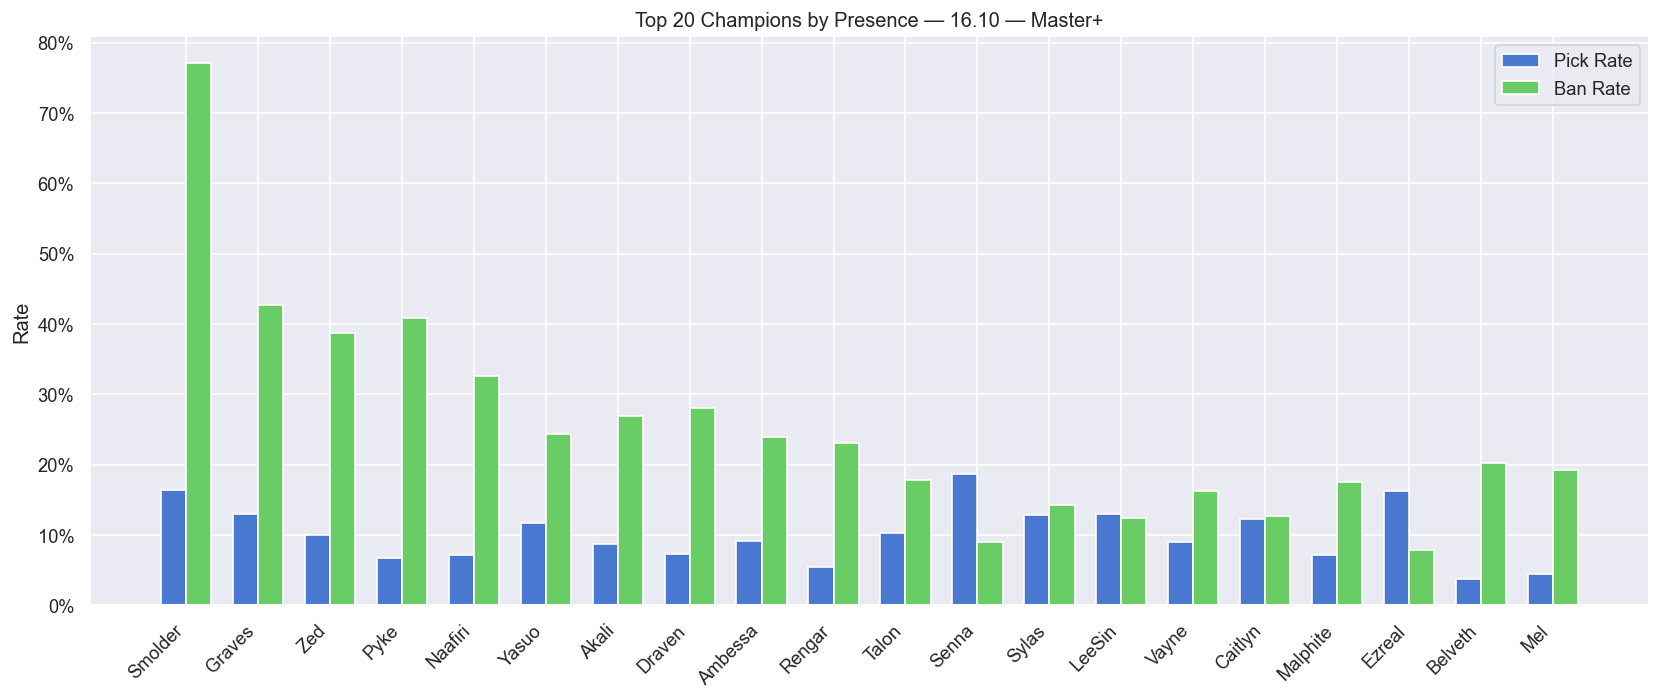

In [5]:
# Top 20 champions by presence rate
top_presence = presence_df.head(20).copy()

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(top_presence))
bar_width = 0.35

pick_totals = (
    top_presence["picks_top"] + top_presence["picks_jungle"] +
    top_presence["picks_middle"] + top_presence["picks_bottom"] +
    top_presence["picks_support"]
) / top_presence["total_matches"]

ax.bar([i - bar_width/2 for i in x], pick_totals, bar_width, label="Pick Rate", color=sns.color_palette()[0])
ax.bar([i + bar_width/2 for i in x], top_presence["ban_rate"], bar_width, label="Ban Rate", color=sns.color_palette()[2])

ax.set_xticks(list(x))
ax.set_xticklabels(top_presence["champion"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_title(f"Top 20 Champions by Presence — {VERSION} — {tier_label(TIER)}")
ax.set_ylabel("Rate")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Best Champions by Lane
Win rate rankings per lane, filtered by minimum game count.

In [6]:
LANE = "MIDDLE" # Change to TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY

best_df = get_best_champions(db_path=DERIVED_DB, lane=LANE, tier=TIER, version=VERSION, min_games=MIN_GAMES)
best_df.head(20)

,champion,games,wins,win_rate,avg_kda,avg_cs,avg_damage_to_champions
0,Tryndamere,136,84,0.6176,3.45,232.8,23540.0
1,Neeko,101,60,0.5941,3.91,200.2,23979.0
2,Quinn,158,91,0.5759,3.38,170.6,28617.0
3,Zac,121,67,0.5537,4.50,184.9,19529.0
4,LeeSin,82,45,0.5488,2.97,202.2,24887.0
5,Riven,537,292,0.5438,3.32,206.8,20972.0
6,Karma,74,40,0.5405,4.94,185.3,23431.0
7,TwistedFate,1440,771,0.5354,4.19,203.2,19680.0
8,Kennen,161,86,0.5342,3.81,209.0,27747.0
9,Gragas,221,118,0.5339,3.61,195.9,25284.0


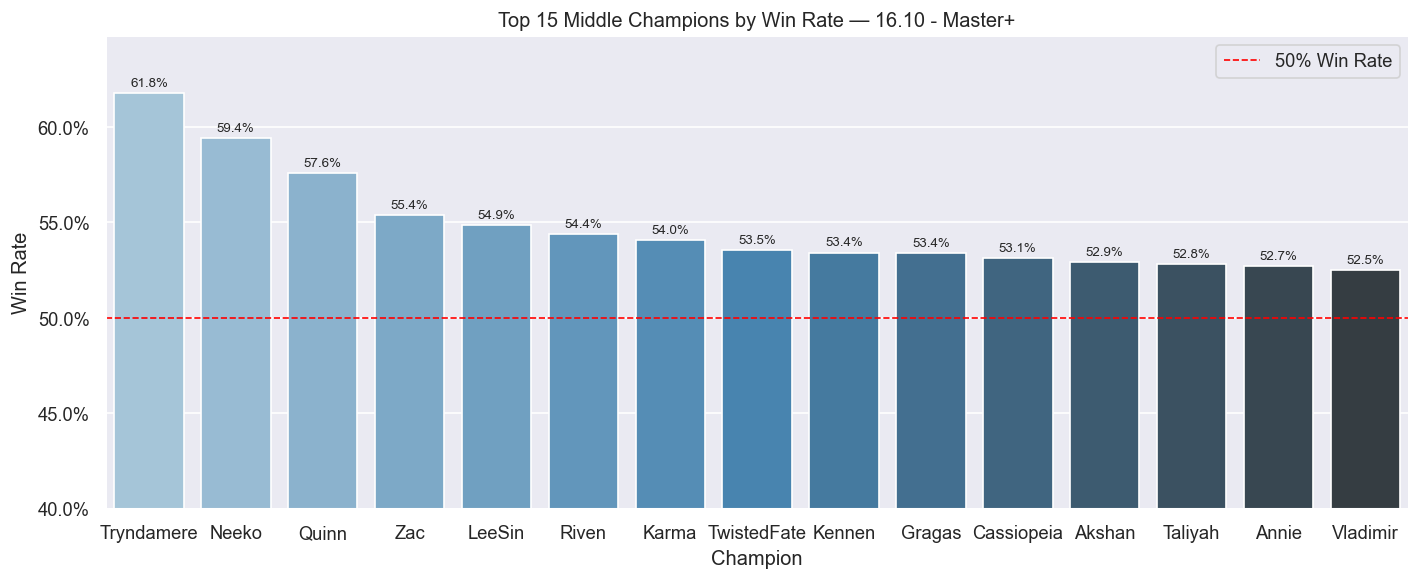

In [7]:
# Top 15 champions by win rate for the selected lane
top_15 = best_df.head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = sns.barplot(
    data=top_15,
    x="champion",
    y="win_rate",
    hue="champion",
    palette="Blues_d",
    legend=False,
    ax=ax
)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50% Win Rate")

for bar, (_, row) in zip(bars.patches, top_15.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{row['win_rate']:.1%}",
        ha="center", va="bottom", fontsize=8
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_title(f"Top 15 {LANE.title()} Champions by Win Rate — {VERSION} - {tier_label(TIER)}")
ax.set_xlabel("Champion")
ax.set_ylabel("Win Rate")
ax.set_ylim(0.4, best_df["win_rate"].max() + 0.03)
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Patch Trends
Win rate evolution across patches for a specific champion.

In [8]:
TREND_CHAMPION = "Ahri" # Change to any champion e.g. "Ahri"
TREND_LANE = "MIDDLE" # Change to TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY

TREND_CHAMPION = _normalize_champion(DERIVED_DB, TREND_CHAMPION)

trends_df = get_patch_trends(db_path=DERIVED_DB, champion=TREND_CHAMPION, lane=TREND_LANE, tier=TIER, min_games=10)
trends_df

,game_version,games,wins,win_rate,avg_kda,avg_cs,avg_damage_to_champions
0,16.9,1240,651,0.5250,3.81,209.1,24051.0
1,16.10,2393,1215,0.5077,3.91,210.7,23809.0


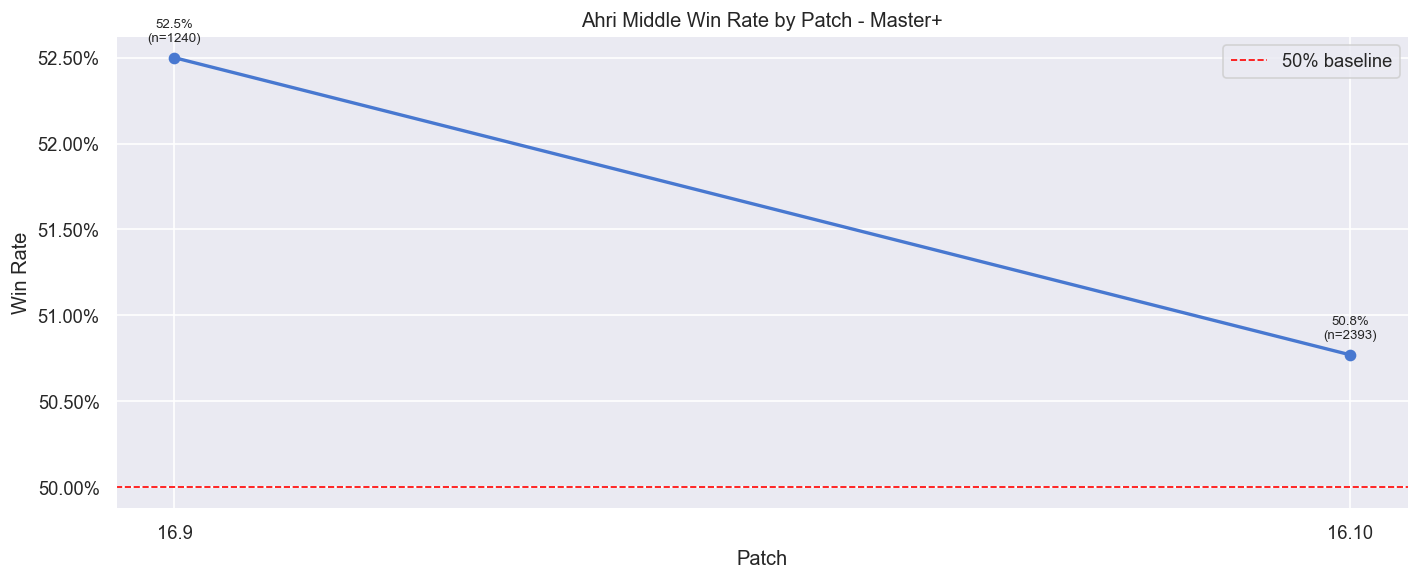

In [9]:
if trends_df.empty:
    print(f"No data for {TREND_CHAMPION} {TREND_LANE} with current filters.")
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(trends_df["game_version"], trends_df["win_rate"], marker="o", linewidth=2)
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50% baseline")

    for _, row in trends_df.iterrows():
        ax.annotate(
            f"{row['win_rate']:.1%}\n(n={row['games']})",
            (row["game_version"], row["win_rate"]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=8
        )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(f"{TREND_CHAMPION} {TREND_LANE.title()} Win Rate by Patch - {tier_label(TIER)}")
    ax.set_xlabel("Patch")
    ax.set_ylabel("Win Rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 4. Matchups
Best and worst lane matchups for a champion.

In [10]:
MATCHUP_CHAMPION = "Ahri" # Change to any champion e.g. Ahri
MATCHUP_LANE = "MIDDLE" # Change to TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY

MATCHUP_CHAMPION = _normalize_champion(DERIVED_DB, MATCHUP_CHAMPION)

matchups_df = get_matchups(
    db_path=DERIVED_DB,
    champion=MATCHUP_CHAMPION,
    lane=MATCHUP_LANE,
    tier=TIER,
    version=VERSION,
    min_games=MIN_MATCHUP_GAMES
)
matchups_df

,opponent,games,champion_wins,win_rate
0,Orianna,31,23,0.7419
1,Xerath,26,19,0.7308
2,Akali,26,17,0.6538
3,Vladimir,29,18,0.6207
4,Sylas,59,36,0.6102
5,Aurora,28,16,0.5714
6,Yasuo,39,22,0.5641
7,Viktor,79,43,0.5443
8,Lissandra,39,21,0.5385
9,TwistedFate,34,18,0.5294


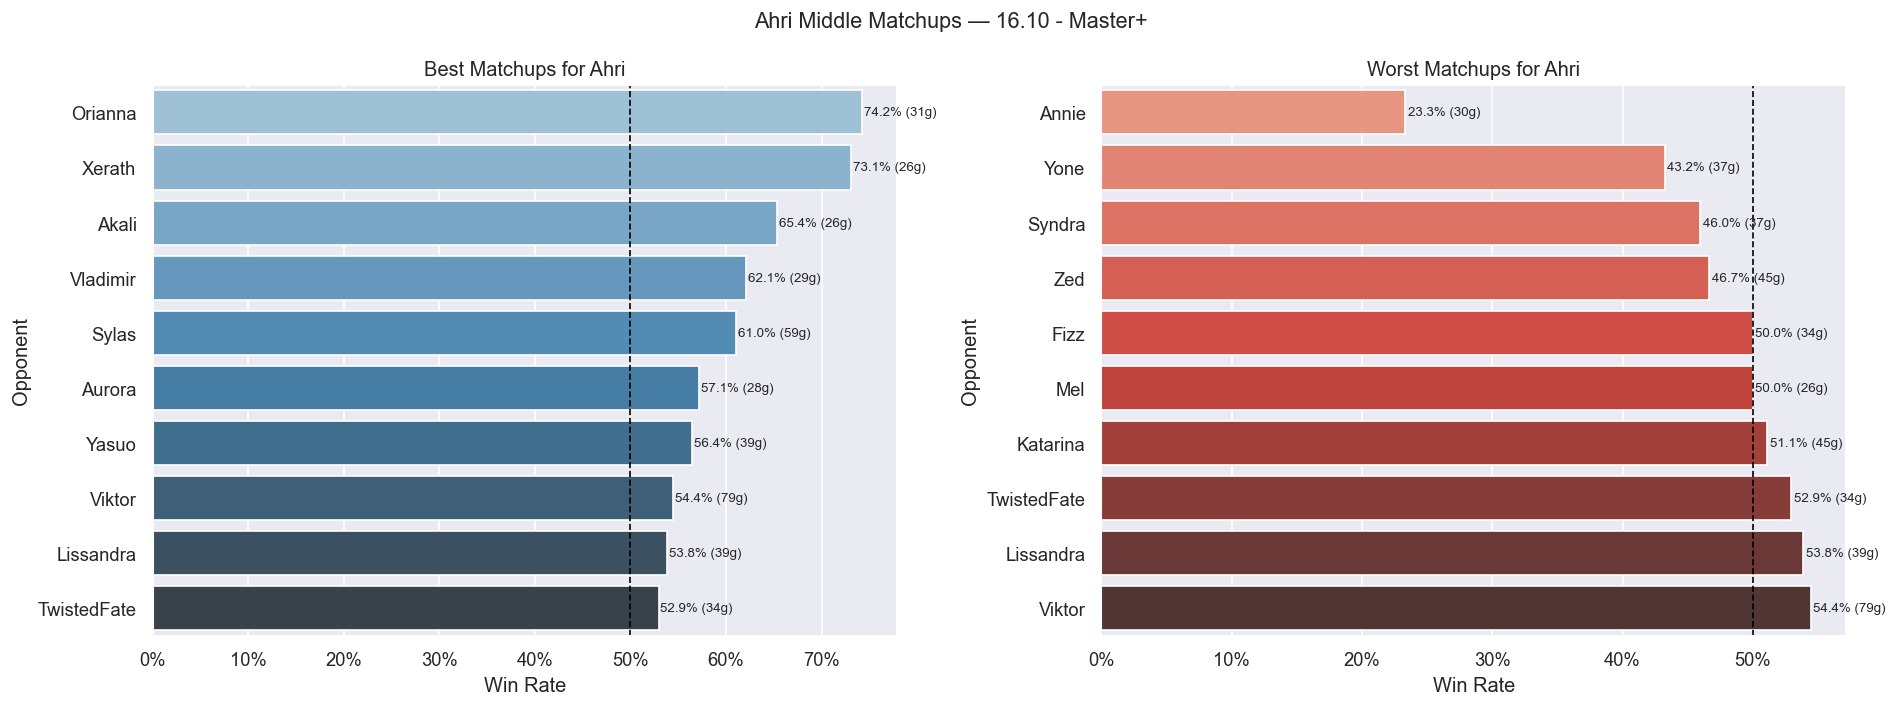

In [11]:
if matchups_df.empty:
    print(f"No matchup data for {MATCHUP_CHAMPION} {MATCHUP_LANE} with current filters.")
else:
    # Show top 10 best and worst matchups
    best_matchups  = matchups_df.head(10)
    worst_matchups = matchups_df.tail(10).iloc[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, data, title, color in zip(
        axes,
        [best_matchups, worst_matchups],
        [f"Best Matchups for {MATCHUP_CHAMPION}", f"Worst Matchups for {MATCHUP_CHAMPION}"],
        ["Blues_d", "Reds_d"]
    ):
        sns.barplot(data=data, x="win_rate", y="opponent", hue="opponent", palette=color, legend=False, ax=ax)
        ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
        ax.set_title(title)
        ax.set_xlabel("Win Rate")
        ax.set_ylabel("Opponent")

        for bar, (_, row) in zip(ax.patches, data.iterrows()):
            ax.text(
                bar.get_width() + 0.002,
                bar.get_y() + bar.get_height() / 2,
                f"{row['win_rate']:.1%} ({row['games']}g)",
                va="center", fontsize=8
            )

    plt.suptitle(f"{MATCHUP_CHAMPION} {MATCHUP_LANE.title()} Matchups — {VERSION} - {tier_label(TIER)}", fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 5. Synergies
Best teammate combinations for a champion.

In [12]:
SYNERGY_CHAMPION = "Ahri" # Change to any champion e.g. "Ahri"
SYNERGY_LANE = "MIDDLE" # Change to TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY

SYNERGY_CHAMPION = _normalize_champion(DERIVED_DB, SYNERGY_CHAMPION)

synergies_df = get_synergies(
    db_path=DERIVED_DB,
    champion=SYNERGY_CHAMPION,
    lane=SYNERGY_LANE,
    tier=TIER,
    version=VERSION,
    min_games=MIN_MATCHUP_GAMES
)
synergies_df.head(20)

,ally_champion,ally_lane,games,wins,win_rate
0,Kennen,TOP,30,22,0.7333
1,Shyvana,JUNGLE,62,44,0.7097
2,Skarner,JUNGLE,30,20,0.6667
3,Poppy,UTILITY,32,21,0.6563
4,Olaf,TOP,58,38,0.6552
5,Teemo,TOP,54,35,0.6481
6,Brand,UTILITY,34,22,0.6471
7,Corki,BOTTOM,67,43,0.6418
8,FiddleSticks,JUNGLE,30,19,0.6333
9,Pantheon,TOP,57,36,0.6316


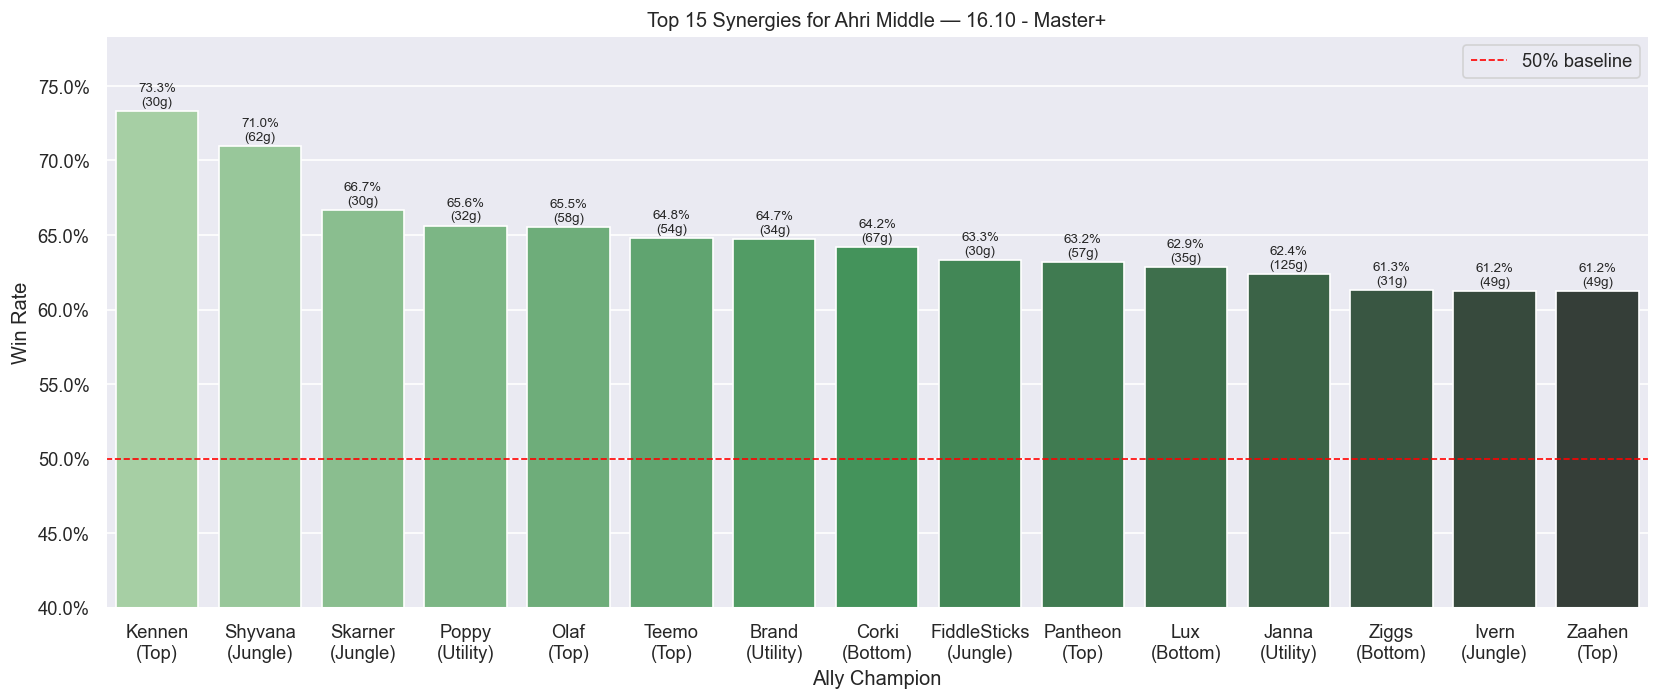

In [13]:
if synergies_df.empty:
    print(f"No synergy data for {SYNERGY_CHAMPION} {SYNERGY_LANE} with current filters.")
else:
    top_synergies = synergies_df.head(15).copy()
    top_synergies["label"] = top_synergies["ally_champion"] + "\n(" + top_synergies["ally_lane"].str.title() + ")"

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=top_synergies, x="label", y="win_rate", hue="label", palette="Greens_d", legend=False, ax=ax)

    ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="50% baseline")

    for bar, (_, row) in zip(ax.patches, top_synergies.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{row['win_rate']:.1%}\n({row['games']}g)",
            ha="center", va="bottom", fontsize=8
        )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(f"Top 15 Synergies for {SYNERGY_CHAMPION} {SYNERGY_LANE.title()} — {VERSION} - {tier_label(TIER)}")
    ax.set_xlabel("Ally Champion")
    ax.set_ylabel("Win Rate")
    ax.set_ylim(0.4, synergies_df["win_rate"].max() + 0.05)
    ax.legend()
    plt.tight_layout()
    plt.show()